In [3]:
import arviz as az
import pandas as pd
import numpy as np

# Load the results from your long run, this is very fast!
idata = az.from_netcdf("../result/mirt_mcmc_converged.nc")

# Now you can perform all of Step E (evaluation, plotting, etc.)
# without ever having to wait for the sampler again.
# For example, to get the ability DataFrame:
ability_means = idata.posterior["theta"].mean(dim=("chain", "draw")).values

--- Saving ability_df_scaled ---
--- Generating Heatmap of Standardized Model Abilities ---


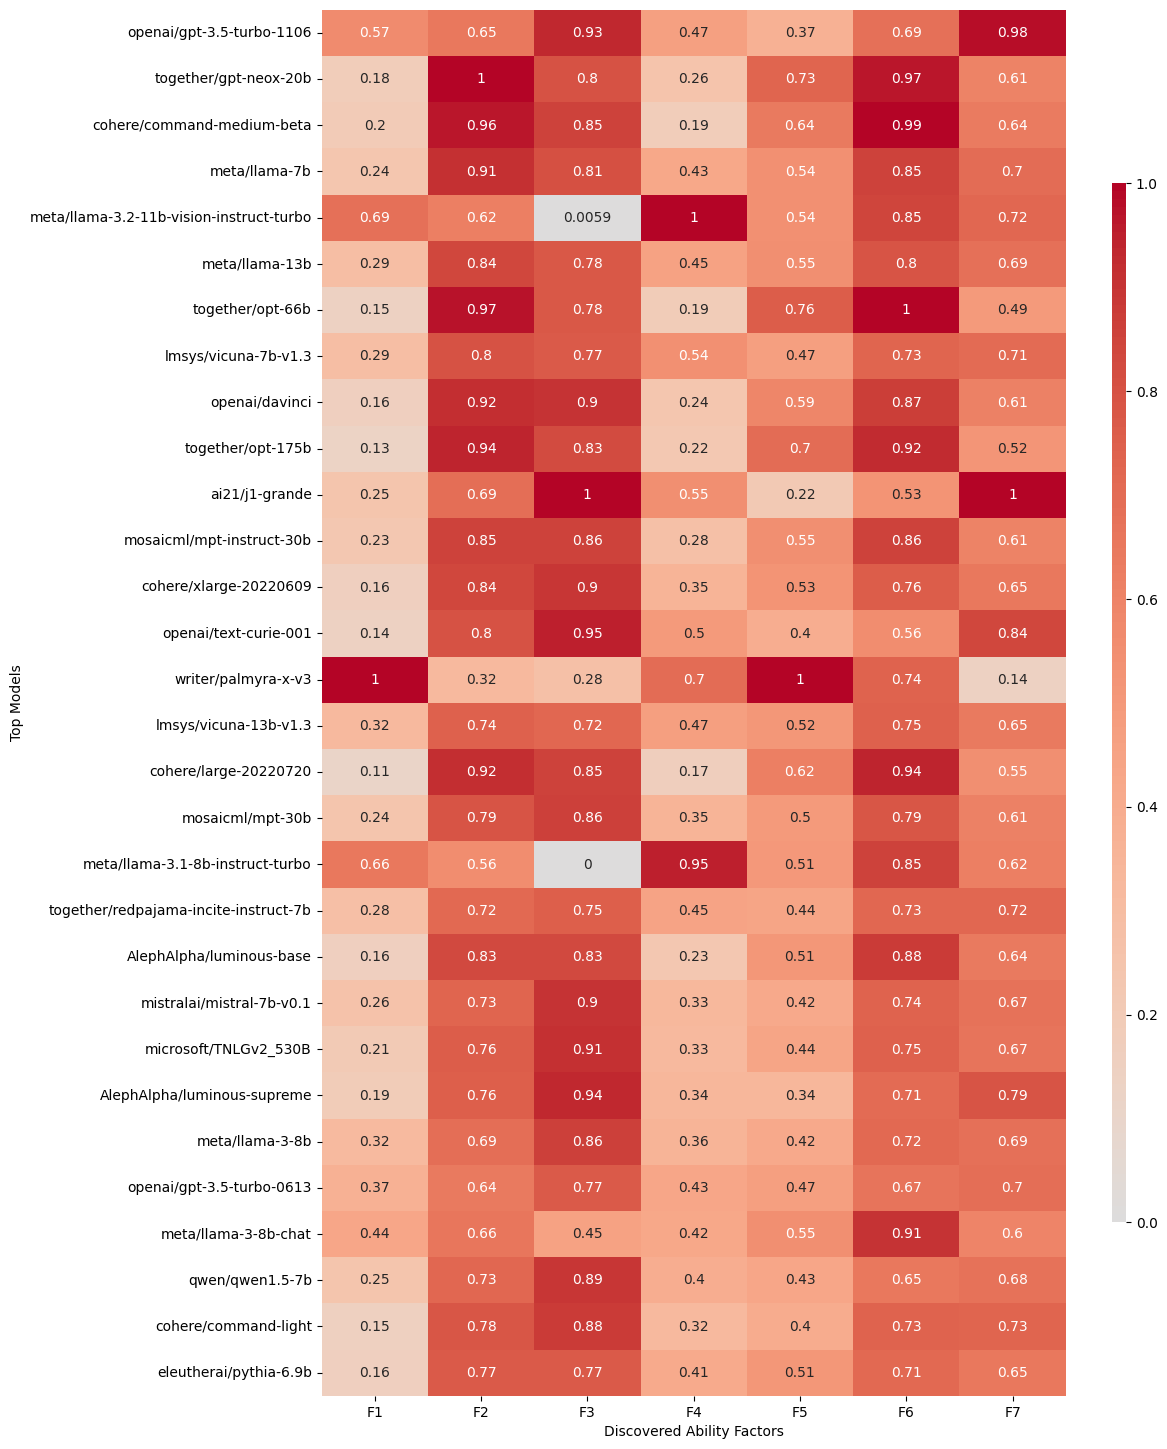

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

resmat = pd.read_pickle("../data/resmat.pkl")
# ===================================================================
# == Step 1: Assume 'idata' is your fitted InferenceData object
# == and 'resmat' is your original DataFrame with model names in the index
# ===================================================================
# This is the standard way to get the posterior mean of your parameters
# The dimensions of theta are ('chain', 'draw', 'theta_dim_0', 'theta_dim_1')
# 'theta_dim_0' corresponds to persons (models) and 'theta_dim_1' to factors (K)
ability_means = idata.posterior["theta"].mean(dim=("chain", "draw")).values
K = 7
# ===================================================================
# == Step 2: Create the DataFrame
# ===================================================================
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(K)] # K is your number of latent dimensions

ability_df = pd.DataFrame(ability_means, index=model_names, columns=factor_names)

# ===================================================================
# == Step 2: Standardize the Ability Scores
# ===================================================================
# Scale each factor (column) to have a mean of 0 and a standard deviation of 1.
scaler = MinMaxScaler()
ability_df_scaled = pd.DataFrame(
    scaler.fit_transform(ability_df),
    index=ability_df.index,
    columns=ability_df.columns
)

# ===================================================================
# == Step 3: Sort and Plot the Heatmap
# ===================================================================
# Sort the DataFrame by the first factor to group the highest-performing models
# ability_df_sorted = ability_df_scaled.sort_values(by='Ability_Factor_1', ascending=False)
print("--- Saving ability_df_scaled ---")
np.save("../result/ability_df_scaled.npy", ability_df_scaled)
print("--- Generating Heatmap of Standardized Model Abilities ---")

k = 30
# Calculate the sum of factor loadings for each model
ability_df_scaled['sum_loadings'] = ability_df_scaled.sum(axis=1)
# Select top k models
top_models = ability_df_scaled.nlargest(k, 'sum_loadings').drop(columns='sum_loadings')

plt.figure(figsize=(12, k * 0.6))
sns.heatmap(
	top_models,
	annot=True,
	cmap='coolwarm',
	center=0,
	cbar_kws={'shrink': 0.75, 'aspect': 75}
)
plt.xlabel('Discovered Ability Factors')
plt.ylabel('Top Models')
plt.savefig(f"../result/standardized-abilities-heatmap-top{k}.png", dpi=300, bbox_inches='tight')
plt.show()

ADVI

In [15]:
import torch

# Load the k8 model
model_data = torch.load('./output/mirt_model_k3.pt', map_location=torch.device('cpu'))

# Extract the parameters
theta = model_data['theta']
a = model_data['a'] 
b = model_data['b']

print(f"Loaded model with shapes:")
print(f"theta: {theta.shape}")
print(f"a: {a.shape}")
print(f"b: {b.shape}")


Loaded model with shapes:
theta: torch.Size([183, 3])
a: torch.Size([78712, 3])
b: torch.Size([78712])


In [ ]:
import pandas as pd
import numpy as np

resmat = pd.read_pickle('../data/resmat_1500.pkl')
np.savetxt('../result/response_data.csv', resmat.values, delimiter=',')
# Convert tensors to numpy arrays and create DataFrames
theta_df = pd.DataFrame(
	theta.detach().cpu().numpy(), 
	index=resmat.index, 
	columns=[f'F{i+1}' for i in range(theta.shape[1])]
)

a_df = pd.DataFrame(
	a.detach().cpu().numpy(), 
	# index=resmat.columns, 
	columns=[f'F{i+1}' for i in range(a.shape[1])]
)

b_df = pd.DataFrame(
	b.detach().cpu().numpy(), 
	# index=resmat.columns, 
	columns=['b']
)

# Export to CSV files
theta_df.to_csv('../result/theta.csv', index=False, header=False)
a_df.to_csv('../result/a.csv', index=False, header=False)
b_df.to_csv('../result/b.csv', index=False, header=False)

print("Exported tensors to CSV files:")
print(f"- theta.csv: {theta_df.shape}")
print(f"- a.csv: {a_df.shape}")
print(f"- b.csv: {b_df.shape}")



Generating ability heatmap...
Top 20 models by sum of abilities:
                                                  F1     F2     F3
request.model                                                     
meta/llama-30b                                 1.775  1.293  4.260
together/glm                                   2.973 -1.321  4.694
anthropic/claude-3-sonnet-20240229             1.552  3.633  0.656
anthropic/claude-3-5-sonnet-20240620           3.490  4.417 -2.068
anthropic/claude-3-opus-20240229               2.792  4.204 -1.379
anthropic/claude-3-5-sonnet-20241022           4.222  3.416 -2.096
tiiuae/falcon-7b                               2.052 -0.889  4.246
ai21/j2-grande                                 0.883  0.305  4.181
openai/text-babbage-001                        3.575 -2.268  3.887
meta/llama-2-7b                                0.752  0.735  3.627
ai21/j1-grande-v2-beta                         0.270 -0.195  4.860
google/gemini-1.5-pro-001-safety-block-none    2.285  2.795 -0.

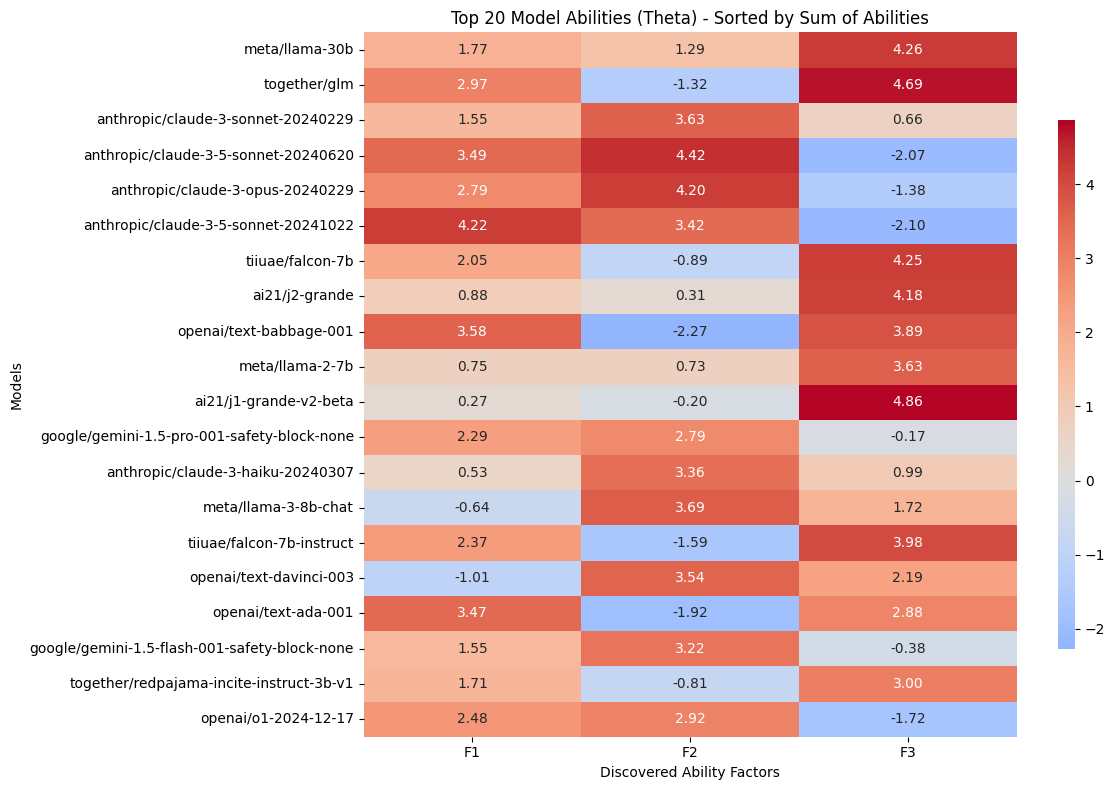


Sum of abilities for top 20 models:
meta/llama-30b: 7.327
together/glm: 6.346
anthropic/claude-3-sonnet-20240229: 5.841
anthropic/claude-3-5-sonnet-20240620: 5.838
anthropic/claude-3-opus-20240229: 5.618
anthropic/claude-3-5-sonnet-20241022: 5.542
tiiuae/falcon-7b: 5.408
ai21/j2-grande: 5.369
openai/text-babbage-001: 5.194
meta/llama-2-7b: 5.114
ai21/j1-grande-v2-beta: 4.934
google/gemini-1.5-pro-001-safety-block-none: 4.914
anthropic/claude-3-haiku-20240307: 4.877
meta/llama-3-8b-chat: 4.770
tiiuae/falcon-7b-instruct: 4.765
openai/text-davinci-003: 4.718
openai/text-ada-001: 4.432
google/gemini-1.5-flash-001-safety-block-none: 4.388
together/redpajama-incite-instruct-3b-v1: 3.896
openai/o1-2024-12-17: 3.673


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

# ===================================================================
# F) Create and Plot the Theta Heatmap
# ===================================================================
print("\nGenerating ability heatmap...")

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta.detach().cpu().numpy()
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)
# iq_scores_df = (ability_df * 15) + 100

# Step 3: Calculate sum of abilities and sort
ability_df['sum_abilities'] = ability_df.sum(axis=1)
ability_df_sorted = ability_df.sort_values(by='sum_abilities', ascending=False)

# Step 4: Set the number of top models to display
k = 20  # Change this value to display top k models
top_models_df = ability_df_sorted.head(k).drop(columns='sum_abilities')

print(f"Top {k} models by sum of abilities:")
print(top_models_df.round(3))

# Step 5: Generate the heatmap using Seaborn
plt.figure(figsize=(12, max(8, k * 0.4)))
sns.heatmap(
	top_models_df,
	annot=True,
	cmap='coolwarm',
	center=0,
	fmt=".2f",
	cbar_kws={'shrink': 0.75, 'aspect': 30}
)
plt.title(f'Top {k} Model Abilities (Theta) - Sorted by Sum of Abilities')
plt.xlabel('Discovered Ability Factors')
plt.ylabel('Models')
plt.tight_layout()
plt.savefig(f"mirt_theta_heatmap_top{k}.png", dpi=300, bbox_inches='tight')
plt.show()

# Optional: Show summary statistics
print(f"\nSum of abilities for top {k} models:")
for model in top_models_df.index:
	sum_ability = ability_df_sorted.loc[model, 'sum_abilities']
	print(f"{model}: {sum_ability:.3f}")


Generating theta correlation heatmap...
Theta Correlation Matrix:
                  F1     F2     F3  sum_abilities
F1             1.000  0.046  0.186          0.738
F2             0.046  1.000 -0.435          0.346
F3             0.186 -0.435  1.000          0.523
sum_abilities  0.738  0.346  0.523          1.000


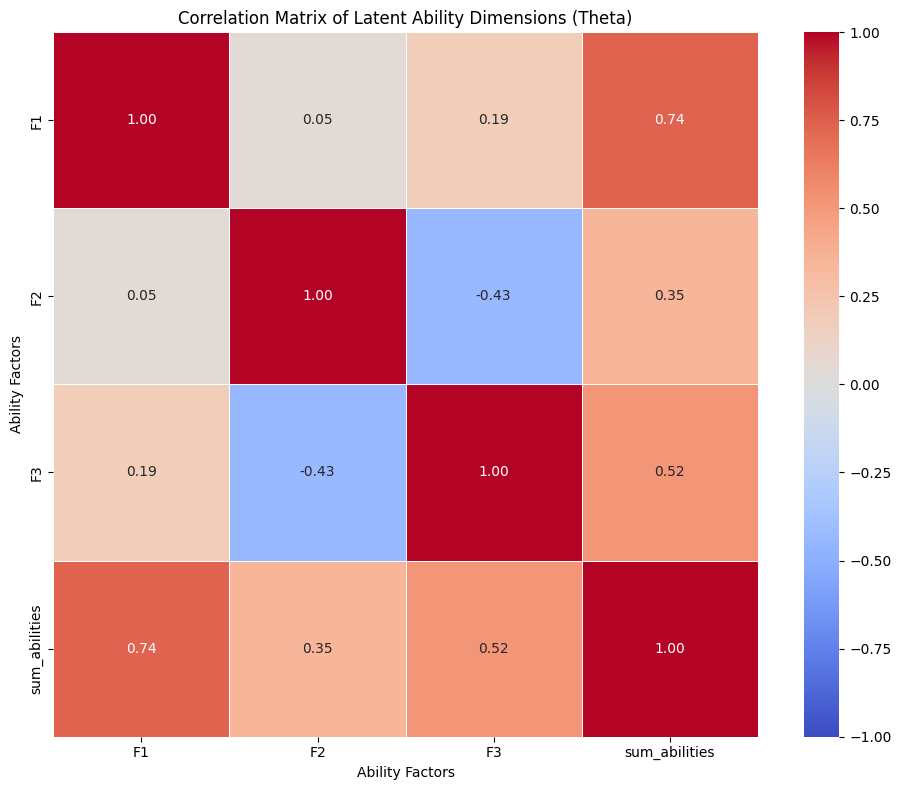

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ===================================================================
# Assume 'ability_df' is already created from your previous code
# ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)
# ===================================================================


# ===================================================================
# G) Calculate and Plot the Theta Correlation Heatmap
# ===================================================================
print("\nGenerating theta correlation heatmap...")

# Step 1: Calculate the correlation matrix
# The .corr() method on a DataFrame computes the pairwise correlation of columns.
theta_corr_matrix = ability_df.corr()

print("Theta Correlation Matrix:")
print(theta_corr_matrix.round(3))

# Step 2: Generate the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    theta_corr_matrix,
    annot=True,        # Display the correlation values on the heatmap
    cmap='coolwarm',   # Use a diverging colormap (blue for neg, red for pos)
    vmin=-1,           # Set the color scale minimum to -1
    vmax=1,            # Set the color scale maximum to +1
    fmt=".2f",         # Format annotations to two decimal places
    linewidths=.5,     # Add lines between cells
    square=True        # Ensure the plot is a square
)
plt.title('Correlation Matrix of Latent Ability Dimensions (Theta)')
plt.xlabel('Ability Factors')
plt.ylabel('Ability Factors')
plt.tight_layout()
plt.savefig("mirt_theta_correlation_heatmap.png", dpi=300)
plt.show()

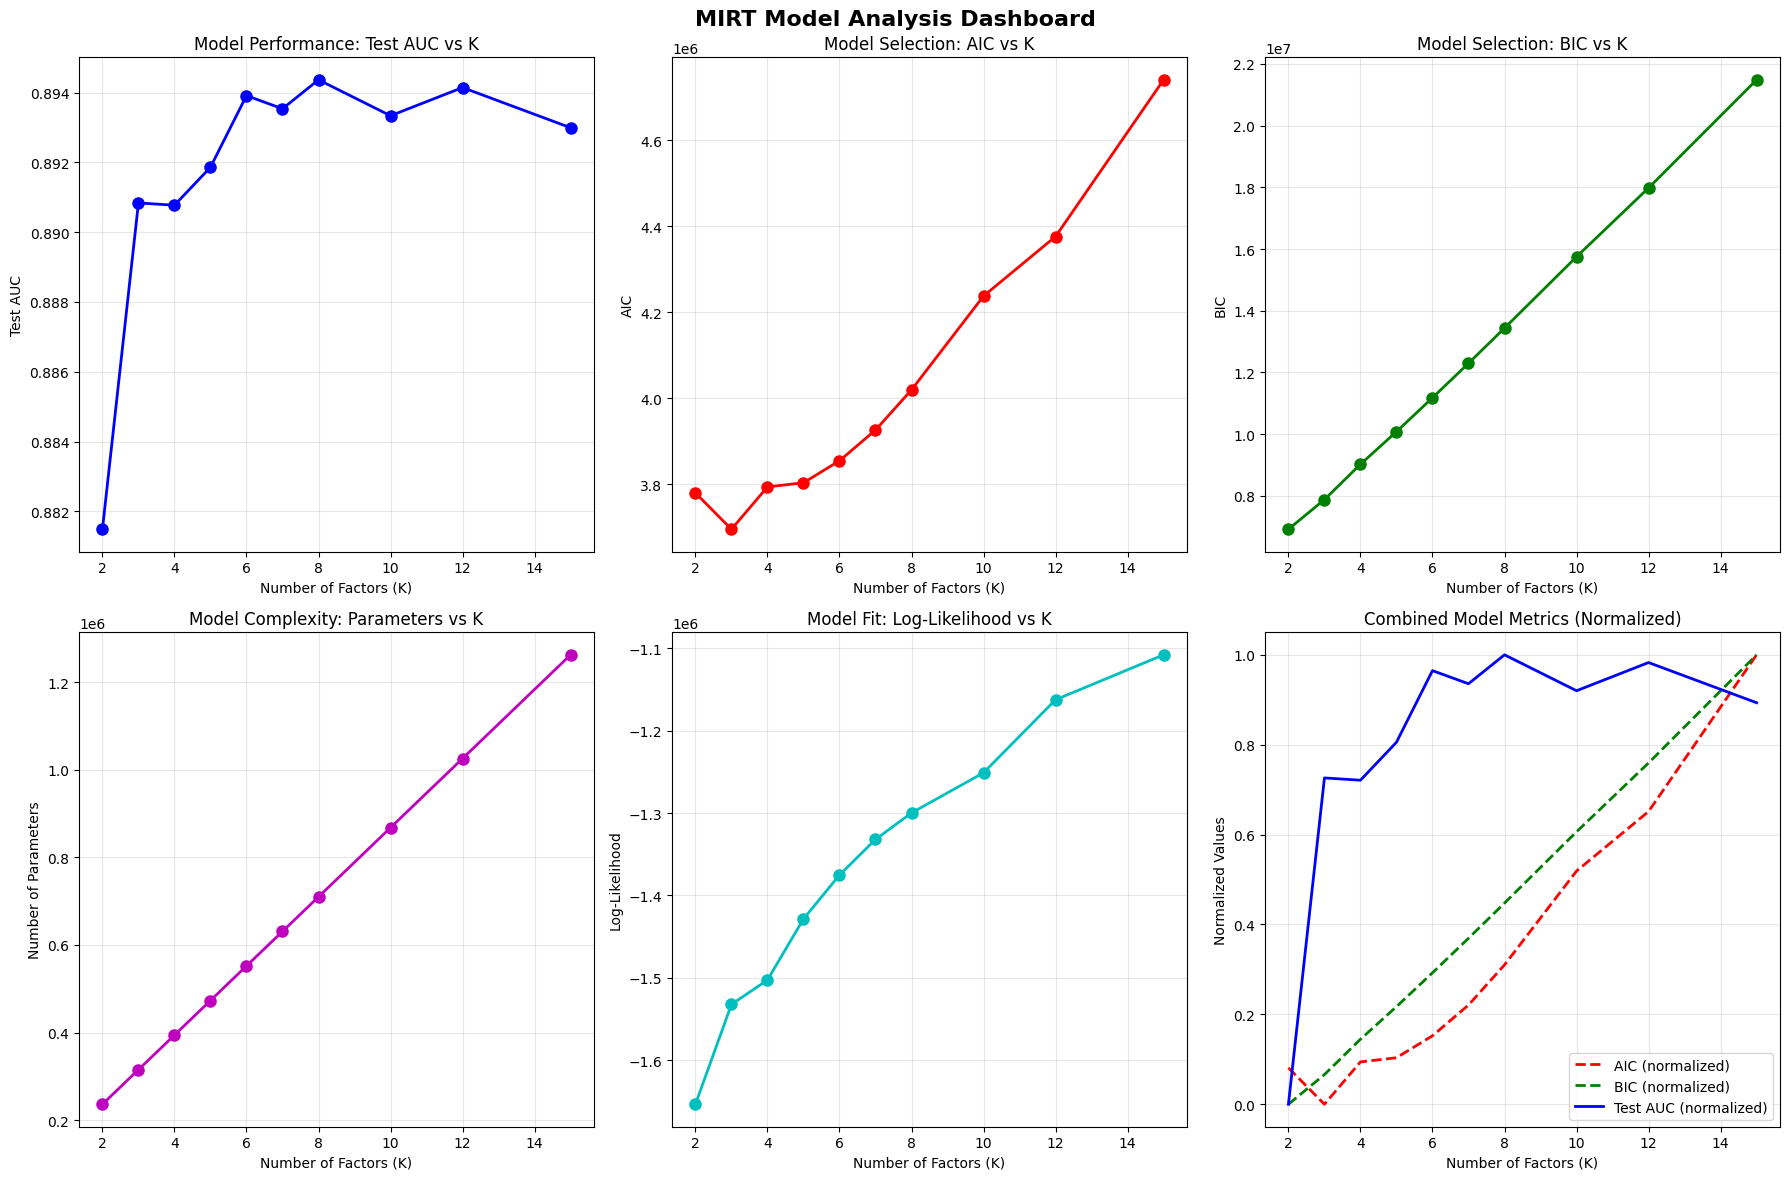

MIRT Model Comprehensive Analysis Summary:
Best AUC: 0.8944 at K=8
Best AIC: 3695469.5 at K=3
Best BIC: 6917544.7 at K=2
Highest Log-Likelihood: -1107995.2 at K=15

Full Results Table:
    Test AUC         AIC           BIC  Num Params  LogLikelihood
K                                                                
2      0.881  3779964.00  6.917545e+06      236502   -1653480.000
3      0.891  3695469.50  7.879720e+06      315397   -1532337.750
4      0.891  3793916.00  9.024836e+06      394292   -1502666.000
5      0.892  3803518.50  1.008111e+07      473187   -1428572.250
6      0.894  3854687.25  1.117895e+07      552082   -1375261.625
7      0.894  3926149.00  1.229708e+07      630977   -1332097.500
8      0.894  4019478.00  1.343708e+07      709872   -1299867.000
10     0.893  4237610.00  1.574855e+07      867662   -1251143.000
12     0.894  4375995.75  1.798027e+07     1025452   -1162545.875
15     0.893  4740264.50  2.148455e+07     1262137   -1107995.250


In [13]:
import matplotlib.pyplot as plt

mirt_results = pd.read_csv("../result/mirt_comparison.csv")


# Create a single figure with all plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('MIRT Model Analysis Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Test AUC vs K
axes[0, 0].plot(mirt_results['K'], mirt_results['Test AUC'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Factors (K)')
axes[0, 0].set_ylabel('Test AUC')
axes[0, 0].set_title('Model Performance: Test AUC vs K')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: AIC vs K
axes[0, 1].plot(mirt_results['K'], mirt_results['AIC'], 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Factors (K)')
axes[0, 1].set_ylabel('AIC')
axes[0, 1].set_title('Model Selection: AIC vs K')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: BIC vs K
axes[0, 2].plot(mirt_results['K'], mirt_results['BIC'], 'go-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Number of Factors (K)')
axes[0, 2].set_ylabel('BIC')
axes[0, 2].set_title('Model Selection: BIC vs K')
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Number of Parameters vs K
axes[1, 0].plot(mirt_results['K'], mirt_results['Num Params'], 'mo-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Factors (K)')
axes[1, 0].set_ylabel('Number of Parameters')
axes[1, 0].set_title('Model Complexity: Parameters vs K')
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Log-Likelihood vs K
axes[1, 1].plot(mirt_results['K'], mirt_results['LogLikelihood'], 'co-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Factors (K)')
axes[1, 1].set_ylabel('Log-Likelihood')
axes[1, 1].set_title('Model Fit: Log-Likelihood vs K')
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Combined comparison (AIC and BIC normalized)
ax6 = axes[1, 2]
# Normalize AIC and BIC to 0-1 scale for comparison
aic_norm = (mirt_results['AIC'] - mirt_results['AIC'].min()) / (mirt_results['AIC'].max() - mirt_results['AIC'].min())
bic_norm = (mirt_results['BIC'] - mirt_results['BIC'].min()) / (mirt_results['BIC'].max() - mirt_results['BIC'].min())
auc_norm = (mirt_results['Test AUC'] - mirt_results['Test AUC'].min()) / (mirt_results['Test AUC'].max() - mirt_results['Test AUC'].min())

ax6.plot(mirt_results['K'], aic_norm, 'r--', label='AIC (normalized)', linewidth=2, markersize=6)
ax6.plot(mirt_results['K'], bic_norm, 'g--', label='BIC (normalized)', linewidth=2, markersize=6)
ax6.plot(mirt_results['K'], auc_norm, 'b-', label='Test AUC (normalized)', linewidth=2, markersize=6)
ax6.set_xlabel('Number of Factors (K)')
ax6.set_ylabel('Normalized Values')
ax6.set_title('Combined Model Metrics (Normalized)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mirt_complete_analysis_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

# Print comprehensive summary
print("MIRT Model Comprehensive Analysis Summary:")
print("=" * 60)
print(f"Best AUC: {mirt_results['Test AUC'].max():.4f} at K={mirt_results.loc[mirt_results['Test AUC'].idxmax(), 'K']}")
print(f"Best AIC: {mirt_results['AIC'].min():.1f} at K={mirt_results.loc[mirt_results['AIC'].idxmin(), 'K']}")
print(f"Best BIC: {mirt_results['BIC'].min():.1f} at K={mirt_results.loc[mirt_results['BIC'].idxmin(), 'K']}")
print(f"Highest Log-Likelihood: {mirt_results['LogLikelihood'].max():.1f} at K={mirt_results.loc[mirt_results['LogLikelihood'].idxmax(), 'K']}")
print("\nFull Results Table:")
print(mirt_results.set_index('K').round(3))